# 03 - XYZ Scar Shape Deep-Dive

Focused analysis of Core Zone cases where the ISOMAP embedding of the largest
scar fragment (F1) shows a 3-armed "Y/XYZ" shape: three radial arms ~120° apart.

Pipeline:
1. Rebuild ISOMAP analyses for the known set (or load from pickle cache)
2. Auto-detect XYZ-shape cases
3. Load clinical data from `develop-vt.csv`
4. Merge imaging + clinical on `patient_id`
5. Clinical profile of XYZ patients
6. XYZ vs non-XYZ statistical comparison
7. Visual overview: 3D renders + ISOMAP embeddings
8. Radial envelope profiles with arm markers

## 0 - Imports & config

In [11]:
import json, pickle, sys
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyvista as pv
from scipy.ndimage import uniform_filter1d
from scipy.signal import find_peaks
from scipy.stats import mannwhitneyu, chi2_contingency
from sklearn.manifold import Isomap
from tqdm import tqdm

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))
from src.data_loading import scan
from src.clinical_data import load as load_clinical, COLUMN_GROUPS

HD_ROOT      = r'F:/RM_TEKNON_DEVELOP'
CLINICAL_CSV = Path(r'C:/Users/joan/Desktop/FEINA/UPF/TFG/develop-vt.csv')
SEED         = 42
RESULTS      = ROOT / 'results'
SPLIT_JSON   = RESULTS / 'split.json'
OUT          = RESULTS / '03_xyz_analysis'
OUT.mkdir(parents=True, exist_ok=True)

# ISOMAP params — must match 01_scar_exploration.ipynb
ISOMAP_PTS         = 800
ISOMAP_K           = 10
MIN_VERTS_FRAGMENT = 30
MIN_VERTS_ISOMAP   = 5
MAX_PLOT_FRAGMENTS = 4
FRAG_COLORS        = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

pv.set_jupyter_backend('static')
plt.rcParams['figure.dpi'] = 120

## 1 - Data loading

In [12]:
all_cases = scan(HD_ROOT)

def has_cz(c):
    p = c.tissue_surfaces.get('core')
    return p is not None and p.exists()

valid = [c for c in all_cases if has_cz(c)]

with open(SPLIT_JSON) as f:
    split = json.load(f)

known_keys = set(split['known'])  # format: "year/patient_id"
known = [c for c in valid if f'{c.year}/{c.patient_id}' in known_keys]
print(f'Valid CZ cases : {len(valid)}')
print(f'Known set      : {len(known)}')

Valid CZ cases : 105
Known set      : 84


## 2 - ISOMAP analysis

Helpers mirrored from `01_scar_exploration.ipynb`. Results are cached to a pickle — re-runs are instant.

In [13]:
@dataclass
class CZAnalysis:
    key:                  str
    raw_n_fragments:      int
    n_fragments:          int
    dropped_fragments:    int
    vertex_counts:        list
    largest_fraction:     float
    centroids:            np.ndarray
    centroid_dist_matrix: np.ndarray
    fragment_meshes:      list
    embeddings:           list

    @property
    def is_compact(self):
        return self.n_fragments == 1


def _run_isomap(pts, k=ISOMAP_K, n_pts=ISOMAP_PTS):
    if len(pts) > n_pts:
        idx = np.random.default_rng(SEED).choice(len(pts), n_pts, replace=False)
        pts = pts[idx]
    k_actual = min(k, len(pts) - 1)
    return Isomap(n_neighbors=k_actual, n_components=2).fit_transform(pts)


def _normalise_embedding(emb):
    emb = np.asarray(emb, dtype=float)
    emb = emb - emb.mean(axis=0, keepdims=True)
    scale = np.linalg.norm(emb, axis=1).max()
    if scale > 0:
        emb = emb / scale
    return emb


def _connected_fragments(mesh):
    labeled = mesh.connectivity(largest=False)
    if 'RegionId' in labeled.cell_data:
        region_ids = np.unique(np.asarray(labeled.cell_data['RegionId']).astype(int))
    elif 'RegionId' in labeled.point_data:
        region_ids = np.unique(np.asarray(labeled.point_data['RegionId']).astype(int))
    else:
        return [mesh]
    fragments = []
    for rid in region_ids:
        piece = labeled.threshold((rid - 0.5, rid + 0.5), scalars='RegionId')
        piece = piece.extract_surface().clean()
        if piece.n_points > 0:
            fragments.append(piece)
    fragments.sort(key=lambda m: m.n_points, reverse=True)
    return fragments


def _filter_fragments(fragments, min_points=MIN_VERTS_FRAGMENT):
    kept = [f for f in fragments if f.n_points >= min_points]
    return kept if kept else fragments[:1]


def analyze_cz(case):
    from scipy.spatial.distance import cdist
    key           = f'{case.year}/{case.patient_id}'
    cz            = pv.read(str(case.tissue_surfaces['core']))
    fragments_all = _connected_fragments(cz)
    raw_n_frags   = len(fragments_all)
    fragments     = _filter_fragments(fragments_all)
    n_frags       = len(fragments)
    if n_frags == 0:
        raise ValueError('no scar fragments')
    dropped = raw_n_frags - n_frags
    vc      = [f.n_points for f in fragments]
    total   = sum(vc)
    lf      = vc[0] / total if total else 0.0
    cents   = np.array([f.center for f in fragments])
    dm      = cdist(cents, cents) if n_frags > 1 else np.zeros((1, 1))
    embeddings = []
    for frag in fragments:
        pts = np.array(frag.points)
        if len(pts) >= MIN_VERTS_ISOMAP:
            try:
                embeddings.append(_normalise_embedding(_run_isomap(pts)))
            except Exception:
                embeddings.append(None)
        else:
            embeddings.append(None)
    return CZAnalysis(
        key=key, raw_n_fragments=raw_n_frags, n_fragments=n_frags,
        dropped_fragments=dropped, vertex_counts=vc, largest_fraction=lf,
        centroids=cents, centroid_dist_matrix=dm,
        fragment_meshes=fragments, embeddings=embeddings,
    )

In [14]:
CACHE_PATH = OUT / 'analyses_cache.pkl'

if CACHE_PATH.exists():
    with open(CACHE_PATH, 'rb') as f:
        analyses = pickle.load(f)
    if analyses:
        print(f'Loaded from cache: {len(analyses)} analyses')
    else:
        print('Cache exists but is empty (stale from a failed run) — deleting and recomputing.')
        CACHE_PATH.unlink()
        analyses = None

if not CACHE_PATH.exists():
    analyses = {}
    for case in tqdm(known, desc='ISOMAP analysis'):
        key = f'{case.year}/{case.patient_id}'
        try:
            analyses[key] = analyze_cz(case)
        except Exception as e:
            print(f'  skip {key}: {e}')
    with open(CACHE_PATH, 'wb') as f:
        pickle.dump(analyses, f)
    print(f'Analysed and cached: {len(analyses)}')

Cache exists but is empty (stale from a failed run) — deleting and recomputing.


ISOMAP analysis:   0%|          | 0/84 [00:00<?, ?it/s]C:\Users\joan\AppData\Local\Temp\ipykernel_23456\1634677100.py:47: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  piece = piece.extract_surface().clean()
C:\Users\joan\AppData\Local\Temp\ipykernel_23456\1634677100.py:47: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  piece = piece.extract_surface().clean()
C:\Users\joan\AppData\Local\Temp\ipykernel_23456\1634677100.py:47: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in th

Analysed and cached: 84


## 3 - XYZ shape detection

Parameters mirror `01_scar_exploration.ipynb` exactly. Edit here to tune sensitivity; re-run section to update `xyz_df`.

In [15]:
XYZ_N_BINS          = 72
XYZ_SMOOTH_BINS     = 5
XYZ_MIN_PEAK_PROM   = 0.07
XYZ_MIN_PEAK_RADIUS = 0.30
XYZ_ARM_SPACING_DEG = 120
XYZ_ARM_TOL_DEG     = 45


def _f1_xyz_signature(analysis, n_bins=XYZ_N_BINS):
    emb = analysis.embeddings[0] if analysis.embeddings else None
    if emb is None or len(emb) < 30:
        return None
    pts = np.asarray(emb, dtype=float)
    pts = pts - pts.mean(axis=0, keepdims=True)
    radii  = np.linalg.norm(pts, axis=1)
    angles = np.arctan2(pts[:, 1], pts[:, 0])
    bins   = np.linspace(-np.pi, np.pi, n_bins + 1)
    mids   = 0.5 * (bins[:-1] + bins[1:])
    idx    = np.clip(np.digitize(angles, bins) - 1, 0, n_bins - 1)
    env    = np.zeros(n_bins, dtype=float)
    for bi, ri in zip(idx, radii):
        env[bi] = max(env[bi], ri)
    smooth   = uniform_filter1d(env, size=XYZ_SMOOTH_BINS, mode='wrap')
    peaks, _ = find_peaks(smooth, prominence=XYZ_MIN_PEAK_PROM,
                          distance=max(4, n_bins // 6))
    peak_angles = (np.degrees(mids[peaks]) + 360) % 360
    peak_radii  = smooth[peaks]
    keep        = peak_radii >= XYZ_MIN_PEAK_RADIUS
    peak_angles = np.sort(peak_angles[keep])
    peak_radii  = peak_radii[keep]
    is_xyz, arm_spacings = False, np.array([])
    if len(peak_angles) == 3:
        arm_spacings = np.diff(np.r_[peak_angles, peak_angles[0] + 360])
        is_xyz = bool(np.all(np.abs(arm_spacings - XYZ_ARM_SPACING_DEG) <= XYZ_ARM_TOL_DEG))
    return {
        'is_xyz': is_xyz,
        'n_peaks': int(len(peak_angles)),
        'peak_angles_deg': np.round(peak_angles, 1).tolist(),
        'peak_radii': np.round(peak_radii, 3).tolist(),
        'arm_spacings_deg': np.round(arm_spacings, 1).tolist(),
    }


_EMPTY_COLS = ['key', 'year', 'patient_id', 'n_fragments', 'raw_n_fragments',
               'largest_fraction', 'f1_vertices', 'is_xyz', 'n_peaks',
               'peak_angles_deg', 'arm_spacings_deg']

rows = []
for analysis in analyses.values():
    sig = _f1_xyz_signature(analysis)
    year, pid = analysis.key.split('/')
    rows.append({
        'key': analysis.key, 'year': int(year), 'patient_id': pid,
        'n_fragments': analysis.n_fragments,
        'raw_n_fragments': analysis.raw_n_fragments,
        'largest_fraction': round(float(analysis.largest_fraction), 3),
        'f1_vertices': int(analysis.vertex_counts[0]) if analysis.vertex_counts else 0,
        'is_xyz': sig['is_xyz'] if sig else False,
        'n_peaks': sig['n_peaks'] if sig else 0,
        'peak_angles_deg': sig['peak_angles_deg'] if sig else [],
        'arm_spacings_deg': sig['arm_spacings_deg'] if sig else [],
    })

if rows:
    all_df = pd.DataFrame(rows).sort_values(['year', 'patient_id']).reset_index(drop=True)
else:
    all_df = pd.DataFrame(columns=_EMPTY_COLS)
    print("WARNING: no analyses found — check that the ISOMAP cache cell ran successfully.")

xyz_df    = all_df[all_df['is_xyz'].astype(bool)].reset_index(drop=True)
nonxyz_df = all_df[~all_df['is_xyz'].astype(bool)].reset_index(drop=True)

print(f'Total analysed : {len(all_df)}')
print(f'XYZ-shape      : {len(xyz_df)}')
print(f'Non-XYZ        : {len(nonxyz_df)}')
if xyz_df.empty:
    print("No XYZ candidates detected.")
else:
    display(xyz_df[['patient_id', 'year', 'n_fragments', 'largest_fraction',
                     'peak_angles_deg', 'arm_spacings_deg']])

Total analysed : 84
XYZ-shape      : 19
Non-XYZ        : 65


,patient_id,year,n_fragments,largest_fraction,peak_angles_deg,arm_spacings_deg
0,15002040,2021,2,0.750,"[132.5, 227.5, 357.5]","[95.0, 130.0, 135.0]"
1,18018648,2021,11,0.255,"[77.5, 222.5, 337.5]","[145.0, 115.0, 100.0]"
2,19033121,2021,10,0.711,"[82.5, 192.5, 347.5]","[110.0, 155.0, 95.0]"
3,20045670,2021,2,0.949,"[137.5, 212.5, 352.5]","[75.0, 140.0, 145.0]"
4,11003916,2022,8,0.764,"[7.5, 127.5, 242.5]","[120.0, 115.0, 125.0]"
5,19036596,2022,34,0.474,"[117.5, 197.5, 357.5]","[80.0, 160.0, 120.0]"
6,50018916,2022,7,0.511,"[87.5, 192.5, 337.5]","[105.0, 145.0, 110.0]"
7,50029831,2022,9,0.852,"[132.5, 217.5, 347.5]","[85.0, 130.0, 145.0]"
8,50038444,2022,8,0.507,"[2.5, 137.5, 227.5]","[135.0, 90.0, 135.0]"
9,00050633,2023,5,0.689,"[132.5, 212.5, 347.5]","[80.0, 135.0, 145.0]"


## 4 - Clinical data

In [16]:
clin = load_clinical(str(CLINICAL_CSV))
print(f'Clinical registry: {len(clin)} patients, {clin.shape[1]} columns')
print()
available_groups = {g: [c for c in cols if c in clin.columns]
                    for g, cols in COLUMN_GROUPS.items()}
for g, cols in available_groups.items():
    if cols:
        print(f'{g:30s}: {cols}')

Clinical registry: 173 patients, 86 columns

demographics                  : ['patient_id', 'date_birth', 'age', 'sex']
risk_factors                  : ['hta', 'dlp', 'dm', 'smoking', 'afib', 'nyha', 'mi_yn']
scar_geometry                 : ['lv_mass_g', 'bz_core_g', 'bz_core_pct', 'bz_g', 'bz_pct', 'core_g', 'core_pct', 'channels', 'channel_mass_g', 'enhancement_distribution', 'enhancement_grade', 'enhancement_territory']
echo                          : ['lvef_pct', 'lvedd_mm', 'lvesd_mm', 'lvedv_ml', 'lvedv_index', 'lvesv_ml', 'lvesv_index', 'la_mm', 'septum_mm', 'post_wall_mm']
devices                       : ['device_carrier', 'date_device_implant', 'device_type', 'icd_prevention_type', 'biomonitor']
arrhythmias                   : ['clinical_va', 'date_clinical_va', 'type_clinical_va', 'soo_clinical_va', 'pvc_burden', 'inducible_va', 'date_eef', 'type_inducible_va', 'soo_inducible_va', 'icd_therapies', 'va_ablation']
followup                      : ['date_6m_followup', 'admission_

## 5 - Merge imaging + clinical

In [17]:
merged      = all_df.merge(clin, on='patient_id', how='left')
xyz_clin    = merged[merged['is_xyz']].reset_index(drop=True)
nonxyz_clin = merged[~merged['is_xyz']].reset_index(drop=True)

print(f'Merged rows             : {len(merged)}')
print(f'XYZ with clinical data  : {xyz_clin["lvef_pct"].notna().sum()} / {len(xyz_clin)}')
print(f'Non-XYZ with clinical   : {nonxyz_clin["lvef_pct"].notna().sum()} / {len(nonxyz_clin)}')

Merged rows             : 84
XYZ with clinical data  : 9 / 19
Non-XYZ with clinical   : 26 / 65


## 6 - Clinical profile of XYZ patients

In [18]:
PROFILE_COLS = [
    'age', 'sex',
    'hta', 'dm', 'dlp', 'smoking', 'afib', 'nyha',
    'lv_mass_g', 'bz_core_g', 'bz_core_pct', 'core_g', 'core_pct',
    'channels', 'channel_mass_g',
    'enhancement_distribution', 'enhancement_territory',
    'lvef_pct', 'lvedv_ml', 'lvesv_ml', 'lvedv_index', 'lvesv_index',
    'device_type', 'icd_prevention_type',
    'clinical_va', 'inducible_va', 'icd_therapies', 'pvc_burden',
    'admission_hf', 'death_yn', 'cardiac_death_yn', 'arrhythmic_death_yn',
]
avail = [c for c in PROFILE_COLS if c in xyz_clin.columns]
display(xyz_clin[['patient_id', 'year'] + avail].reset_index(drop=True))

,patient_id,year,age,sex,hta,dm,dlp,smoking,afib,nyha,...,device_type,icd_prevention_type,clinical_va,inducible_va,icd_therapies,pvc_burden,admission_hf,death_yn,cardiac_death_yn,arrhythmic_death_yn
0,15002040,2021,58.00000,1,0,0,0,2,0,1,...,NaN,NaN,0,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>
1,18018648,2021,78.00000,1,1,1,1,0,4,2,...,2,NaN,0,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>
2,19033121,2021,55.00000,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,NaN,NaN,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>
3,20045670,2021,48.00000,2,1,0,0,2,0,1,...,NaN,NaN,0,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>
4,11003916,2022,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,NaN,NaN,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>
5,19036596,2022,77.68104,1,<NA>,0,<NA>,<NA>,0,<NA>,...,NaN,NaN,<NA>,<NA>,<NA>,NaN,<NA>,0,0,0
6,50018916,2022,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,NaN,NaN,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>
7,50029831,2022,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,NaN,NaN,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>
8,50038444,2022,52.00000,1,0,0,1,2,0,1,...,0,0,0,0,0,0.0,0,0,0,0
9,00050633,2023,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,NaN,NaN,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>


## 7 - XYZ vs non-XYZ comparison

Mann-Whitney U for numeric variables, chi-squared for binary flags.  
p-values are **not corrected** for multiple testing at this exploratory stage.

In [19]:
NUMERIC_COLS = [
    'age', 'lv_mass_g', 'core_g', 'core_pct', 'bz_core_g', 'bz_core_pct',
    'channel_mass_g', 'lvef_pct', 'lvedv_ml', 'lvesv_ml', 'lvedv_index',
    'pvc_burden', 'f1_vertices', 'largest_fraction', 'n_fragments',
]
BINARY_COLS = [
    'hta', 'dm', 'dlp', 'smoking', 'afib', 'channels',
    'clinical_va', 'inducible_va', 'icd_therapies',
    'admission_hf', 'death_yn', 'cardiac_death_yn', 'arrhythmic_death_yn',
]

stat_rows = []
for col in NUMERIC_COLS:
    if col not in merged.columns:
        continue
    xv = xyz_clin[col].dropna()
    nv = nonxyz_clin[col].dropna()
    if len(xv) < 3 or len(nv) < 3:
        continue
    _, p = mannwhitneyu(xv, nv, alternative='two-sided')
    stat_rows.append({
        'variable': col, 'type': 'numeric',
        'xyz_n': len(xv),
        'xyz_median': round(xv.median(), 2),
        'xyz_iqr': f'{xv.quantile(0.25):.1f}-{xv.quantile(0.75):.1f}',
        'nonxyz_n': len(nv),
        'nonxyz_median': round(nv.median(), 2),
        'nonxyz_iqr': f'{nv.quantile(0.25):.1f}-{nv.quantile(0.75):.1f}',
        'p_value': round(p, 4),
    })

for col in BINARY_COLS:
    if col not in merged.columns:
        continue
    xv = xyz_clin[col].dropna()
    nv = nonxyz_clin[col].dropna()
    if len(xv) < 3 or len(nv) < 3:
        continue
    ct = pd.crosstab(merged['is_xyz'], merged[col])
    if ct.shape == (2, 2):
        _, p, _, _ = chi2_contingency(ct)
        stat_rows.append({
            'variable': col, 'type': 'binary',
            'xyz_n': len(xv),
            'xyz_median': f'{xv.mean()*100:.0f}%',
            'xyz_iqr': '',
            'nonxyz_n': len(nv),
            'nonxyz_median': f'{nv.mean()*100:.0f}%',
            'nonxyz_iqr': '',
            'p_value': round(p, 4),
        })

stat_df = pd.DataFrame(stat_rows).sort_values('p_value').reset_index(drop=True)
display(stat_df)

,variable,type,xyz_n,xyz_median,xyz_iqr,nonxyz_n,nonxyz_median,nonxyz_iqr,p_value
0,channel_mass_g,numeric,16,1.64,0.8-4.1,55,0.64,0.0-2.4,0.0399
1,f1_vertices,numeric,19,1146.0,509.0-1915.0,65,462.0,166.0-1240.0,0.0659
2,core_g,numeric,16,1.32,0.7-1.9,55,0.67,0.4-1.6,0.0781
3,channels,binary,16,88%,,55,60%,,0.0807
4,n_fragments,numeric,19,8.0,6.0-11.0,65,5.0,3.0-15.0,0.0844
5,core_pct,numeric,16,1.16,0.7-1.5,55,0.66,0.3-1.3,0.0958
6,age,numeric,10,56.5,52.5-64.0,27,67.0,61.0-73.5,0.1002
7,lvedv_index,numeric,9,91.0,79.0-123.0,26,79.5,68.8-91.5,0.1216
8,clinical_va,binary,7,0%,,21,38%,,0.1473
9,lvesv_ml,numeric,9,85.0,68.0-127.0,26,64.0,51.0-94.8,0.1801


## 8 - Visual overview: 3D render + ISOMAP per XYZ patient

In [20]:
def _best_shell(case):
    for key in ('lv', 'myocardium', 'endo', 'epi'):
        p = case.anatomy.get(key)
        if p is not None and p.exists():
            return pv.read(str(p))
    return None


def _plot_isomap_with_arms(ax, analysis):
    emb = analysis.embeddings[0] if analysis.embeddings else None
    if emb is None or len(emb) == 0:
        ax.text(0.5, 0.5, 'no emb', ha='center', va='center',
                fontsize=8, transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
        return
    pts = np.asarray(emb, dtype=float)
    pts = pts - pts.mean(axis=0, keepdims=True)
    ax.scatter(pts[:, 0], pts[:, 1], s=3, c='tab:blue', alpha=0.6, linewidths=0)
    sig = _f1_xyz_signature(analysis)
    if sig:
        radii  = np.linalg.norm(pts, axis=1)
        angles = np.arctan2(pts[:, 1], pts[:, 0])
        bins   = np.linspace(-np.pi, np.pi, XYZ_N_BINS + 1)
        mids   = 0.5 * (bins[:-1] + bins[1:])
        idx    = np.clip(np.digitize(angles, bins) - 1, 0, XYZ_N_BINS - 1)
        env    = np.zeros(XYZ_N_BINS, dtype=float)
        for bi, ri in zip(idx, radii):
            env[bi] = max(env[bi], ri)
        env = uniform_filter1d(env, size=XYZ_SMOOTH_BINS, mode='wrap')
        for adeg in sig['peak_angles_deg']:
            arad = np.radians(adeg)
            bi   = int(np.clip(np.argmin(np.abs(mids - arad)), 0, XYZ_N_BINS - 1))
            r    = env[bi]
            ax.annotate('', xy=(r * np.cos(arad), r * np.sin(arad)), xytext=(0, 0),
                        arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
    year, pid = analysis.key.split('/')
    ax.set_title(pid, fontsize=8, pad=2)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect('equal', adjustable='datalim')


def _render_3d(analysis, case=None):
    pl = pv.Plotter(off_screen=True, window_size=(520, 340))
    pl.set_background('white')
    if case is not None:
        shell = _best_shell(case)
        if shell is not None:
            pl.add_mesh(shell, color='#cccccc', opacity=0.15,
                        smooth_shading=True, show_scalar_bar=False)
    for fi, frag in enumerate(analysis.fragment_meshes[:MAX_PLOT_FRAGMENTS]):
        pl.add_mesh(frag, color=FRAG_COLORS[fi % len(FRAG_COLORS)],
                    smooth_shading=True, opacity=0.95, show_scalar_bar=False)
        pl.add_point_labels([np.asarray(frag.center)], [f'F{fi+1}'],
                            font_size=12, point_size=0, text_color='black',
                            shape_opacity=0.0, always_visible=True)
    pl.view_isometric()
    pl.camera.zoom(1.25)
    img = pl.screenshot(None, return_img=True)
    pl.close()
    return img

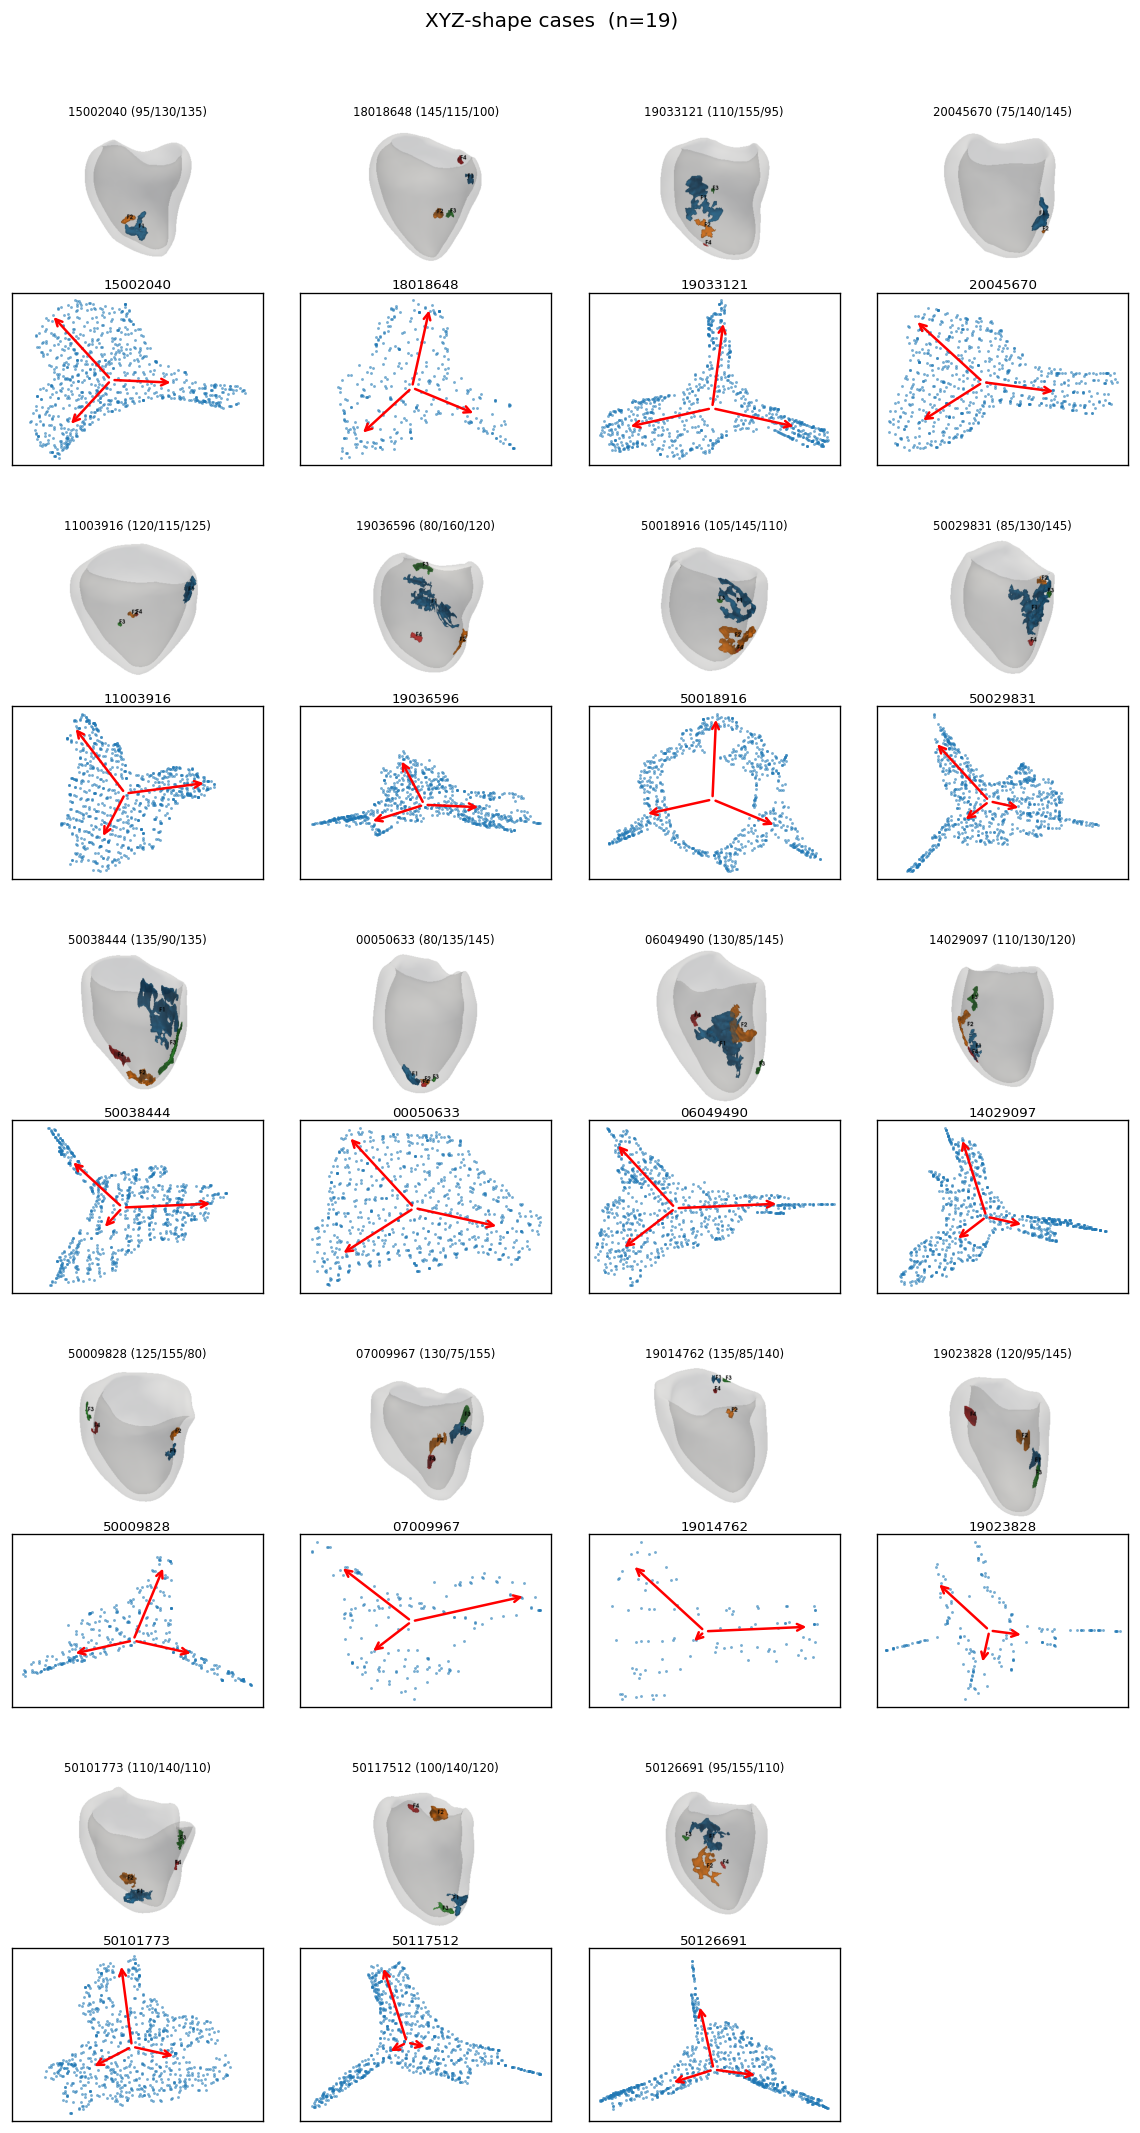

In [21]:
if xyz_df.empty:
    print('No XYZ cases detected.')
else:
    XYZ_NCOLS = 4
    xyz_keys  = list(xyz_df['key'])
    nrows     = max(1, int(np.ceil(len(xyz_keys) / XYZ_NCOLS)))
    fig = plt.figure(figsize=(XYZ_NCOLS * 3.0, nrows * 3.8))
    fig.suptitle(f'XYZ-shape cases  (n={len(xyz_keys)})', fontsize=12, y=0.975)
    outer = fig.add_gridspec(nrows, XYZ_NCOLS,
                             top=0.93, bottom=0.05, hspace=0.18, wspace=0.15)
    for i, key in enumerate(xyz_keys):
        row_o, col_o = divmod(i, XYZ_NCOLS)
        inner = outer[row_o, col_o].subgridspec(2, 1, hspace=0.03,
                                                height_ratios=[1.0, 1.0])
        ax3d  = fig.add_subplot(inner[0])
        axiso = fig.add_subplot(inner[1])
        analysis = analyses[key]
        year, pid = key.split('/')
        case = next((c for c in known
                     if c.patient_id == pid and str(c.year) == year), None)
        try:
            ax3d.imshow(_render_3d(analysis, case=case))
        except Exception as e:
            ax3d.text(0.5, 0.5, str(e)[:60], ha='center', va='center',
                      fontsize=6, transform=ax3d.transAxes)
        ax3d.axis('off')
        sig = _f1_xyz_signature(analysis)
        sp  = '/'.join(f'{s:.0f}' for s in (sig['arm_spacings_deg'] if sig else []))
        ax3d.set_title(f'{pid} ({sp})', fontsize=7, pad=2)
        try:
            _plot_isomap_with_arms(axiso, analysis)
        except Exception as e:
            axiso.text(0.5, 0.5, str(e)[:60], ha='center', va='center',
                       fontsize=6, transform=axiso.transAxes)
    for i in range(len(xyz_keys), nrows * XYZ_NCOLS):
        row_o, col_o = divmod(i, XYZ_NCOLS)
        fig.add_subplot(outer[row_o, col_o]).axis('off')
    plt.savefig(OUT / 'xyz_cases_overview.png', bbox_inches='tight')
    plt.show()

## 9 - Radial envelope profiles

Smoothed angular radial envelope for each XYZ patient with detected arm directions (red dashed lines).

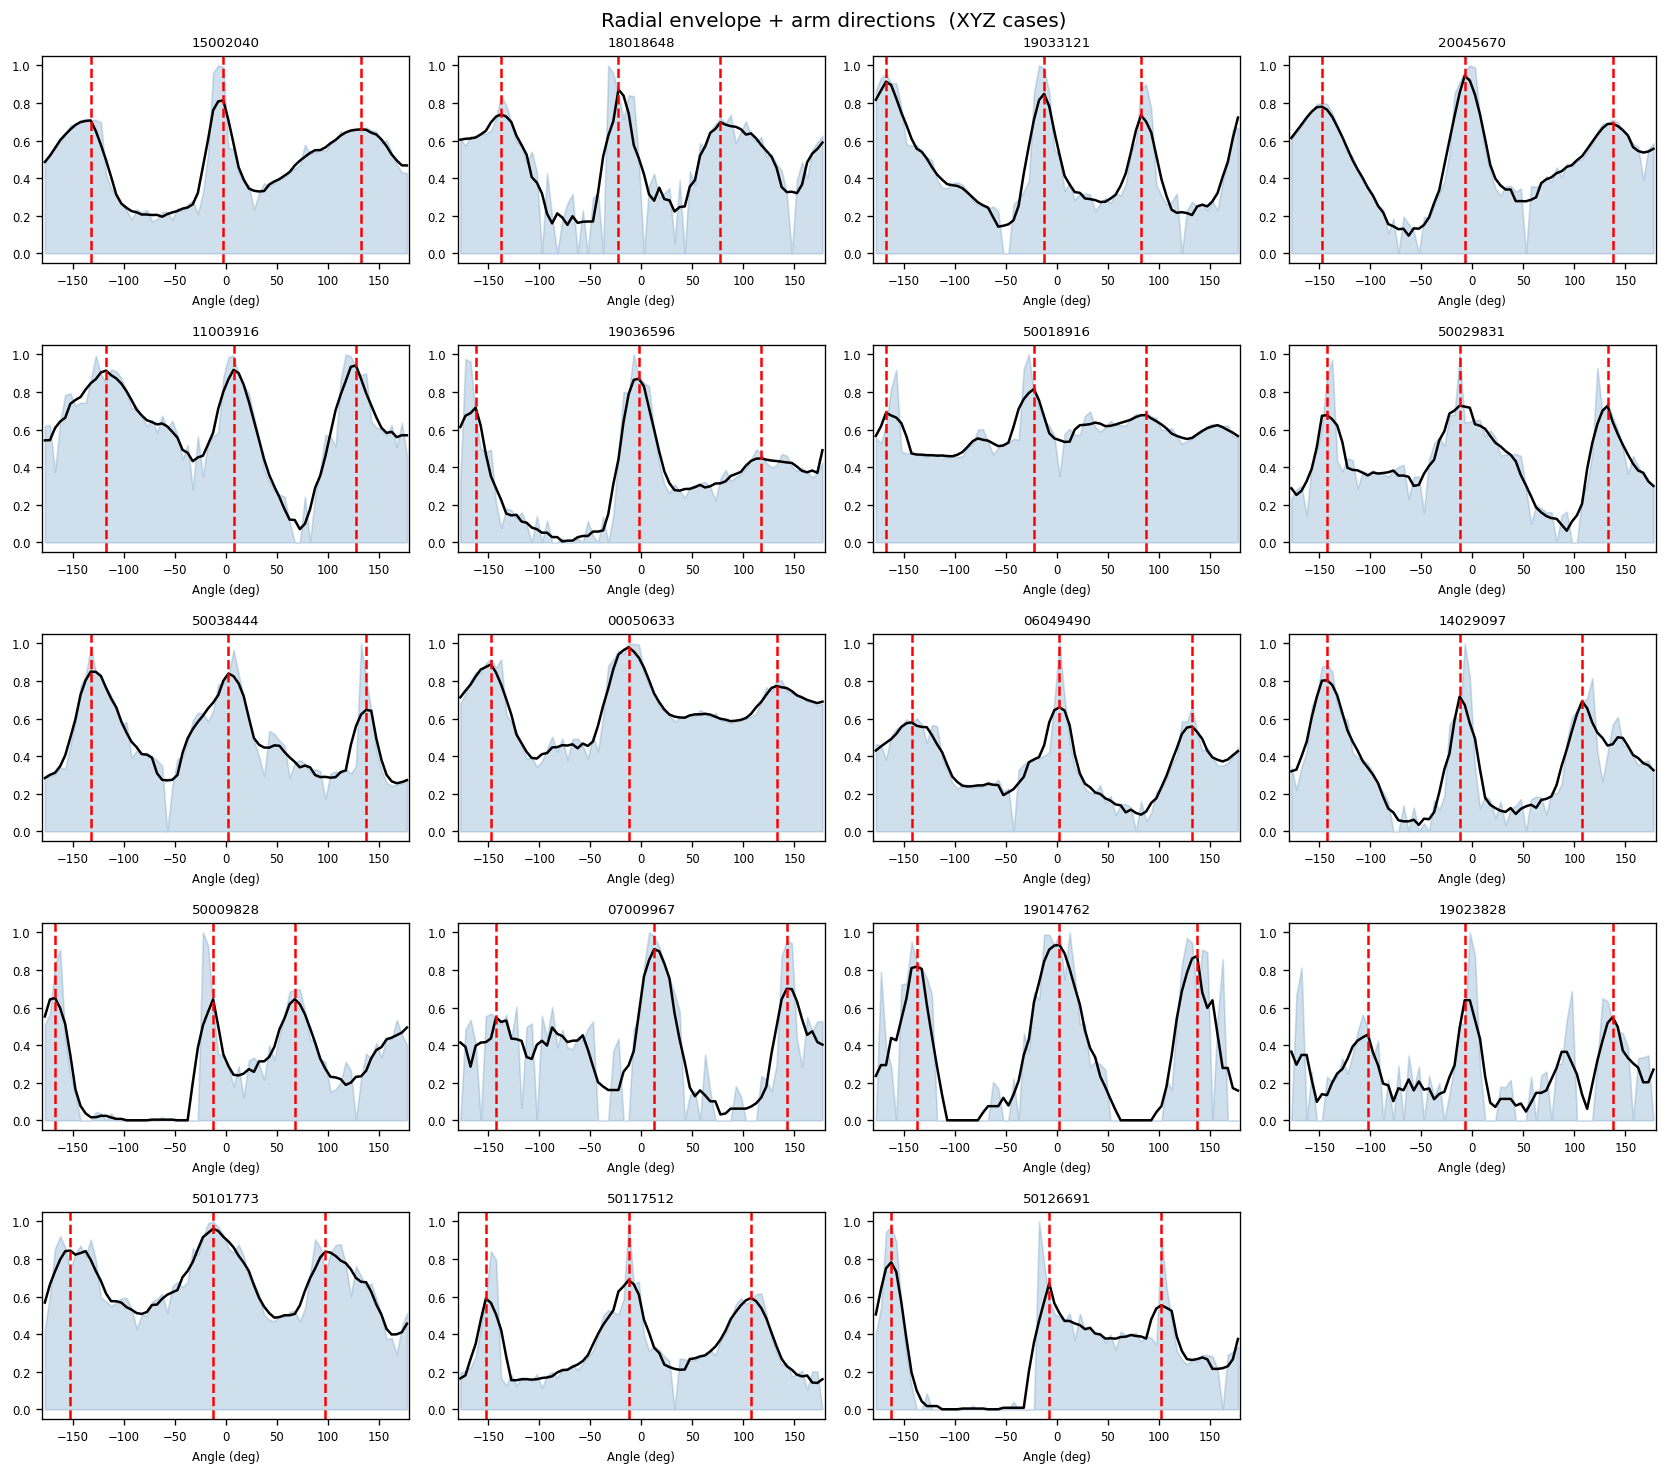

In [22]:
if xyz_df.empty:
    print('No XYZ cases.')
else:
    ncols = 4
    nrows = int(np.ceil(len(xyz_df) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 2.5),
                             squeeze=False)
    axes_flat = axes.reshape(-1)
    fig.suptitle('Radial envelope + arm directions  (XYZ cases)', fontsize=12)
    for i, row in xyz_df.iterrows():
        ax       = axes_flat[i]
        analysis = analyses[row['key']]
        emb      = analysis.embeddings[0] if analysis.embeddings else None
        if emb is None:
            ax.axis('off')
            continue
        pts    = np.asarray(emb, dtype=float)
        pts    = pts - pts.mean(axis=0, keepdims=True)
        radii  = np.linalg.norm(pts, axis=1)
        angles = np.arctan2(pts[:, 1], pts[:, 0])
        bins   = np.linspace(-np.pi, np.pi, XYZ_N_BINS + 1)
        mids   = 0.5 * (bins[:-1] + bins[1:])
        idx    = np.clip(np.digitize(angles, bins) - 1, 0, XYZ_N_BINS - 1)
        env    = np.zeros(XYZ_N_BINS, dtype=float)
        for bi, ri in zip(idx, radii):
            env[bi] = max(env[bi], ri)
        smooth = uniform_filter1d(env, size=XYZ_SMOOTH_BINS, mode='wrap')
        mids_deg = np.degrees(mids)
        ax.fill_between(mids_deg, 0, env, alpha=0.25, color='steelblue')
        ax.plot(mids_deg, smooth, 'k-', lw=1.5)
        sig = _f1_xyz_signature(analysis)
        if sig:
            for adeg in sig['peak_angles_deg']:
                adeg_plot = adeg if adeg <= 180 else adeg - 360
                ax.axvline(adeg_plot, color='red', lw=1.5, ls='--')
        ax.set_xlim(-180, 180)
        ax.set_xlabel('Angle (deg)', fontsize=7)
        ax.set_title(row['patient_id'], fontsize=8)
        ax.tick_params(labelsize=7)
    for j in range(len(xyz_df), len(axes_flat)):
        axes_flat[j].axis('off')
    plt.tight_layout()
    plt.savefig(OUT / 'xyz_radial_envelopes.png', bbox_inches='tight')
    plt.show()

## Outputs

| File | Content |
|---|---|
| `results/03_xyz_analysis/analyses_cache.pkl` | Pickle cache of ISOMAP analyses (reused on re-run) |
| `results/03_xyz_analysis/xyz_cases_overview.png` | 3D renders + ISOMAP for all XYZ patients |
| `results/03_xyz_analysis/xyz_radial_envelopes.png` | Angular radial envelope per XYZ patient |